## Setup Environment & Access Images



In [48]:
pip install gdown

In [49]:
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gdown

# Create a local directory for images if it doesn't exist
local_image_dir = 'image_enhancement'
if not os.path.exists(local_image_dir):
    os.makedirs(local_image_dir)
    print(f"Directory '{local_image_dir}' created.")
else:
    print(f"Directory '{local_image_dir}' already exists.")

# Define the list of images with their filenames and Google Drive URLs
image_info = [
    {"filename": "dark image.jpg", "url": "https://drive.google.com/uc?id=1Rfo58iVjJ_qVlm1L3qmKr_v-2HIJip2f"},
    {"filename": "low contrast.jpg", "url": "https://drive.google.com/uc?id=1hZ0yv2tn-FmVv3HxSzq4xBN-tb26JHye"},
    {"filename": "blurry.jpg", "url": "https://drive.google.com/uc?id=1ssIEhJXvv1IZn0izUsPmI7z42fuL2yHG"},
    {"filename": "too bright.jpg", "url": "https://drive.google.com/uc?id=1LaJcfRo05YW4Mb1zpn0hq5vfGxApyzaF"}
]

# Download each image
for img in image_info:
    filepath = os.path.join(local_image_dir, img["filename"])
    if not os.path.exists(filepath):
        print(f"Downloading {img['filename']}...")
        gdown.download(img["url"], filepath, quiet=False)
        print(f"Downloaded {img['filename']}")
    else:
        print(f"{img['filename']} already exists locally.")

print("All images processed.")

Directory 'image_enhancement' already exists.
dark image.jpg already exists locally.
low contrast.jpg already exists locally.
blurry.jpg already exists locally.
too bright.jpg already exists locally.
All images processed.


## Load and Display Dark Image


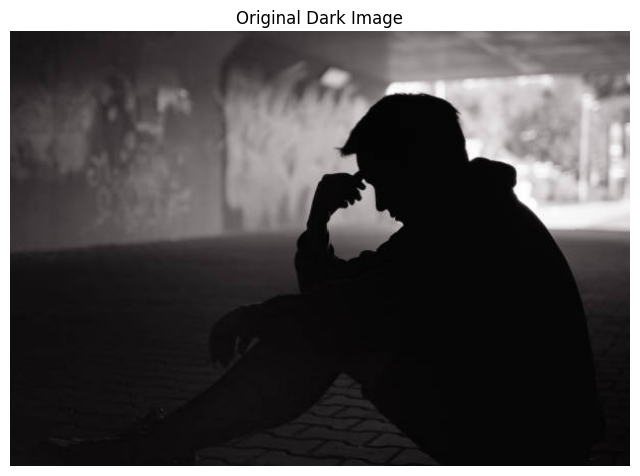

Successfully loaded and displayed 'dark image.jpg'.


In [50]:
dark_image_path = os.path.join(local_image_dir, "dark image.jpg")
dark_image_bgr = cv2.imread(dark_image_path)
dark_image_rgb = cv2.cvtColor(dark_image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(dark_image_rgb)
plt.title('Original Dark Image')
plt.axis('off')
plt.show()

print(f"Successfully loaded and displayed '{os.path.basename(dark_image_path)}'.")

## Enhance Dark Image (Gamma Correction)



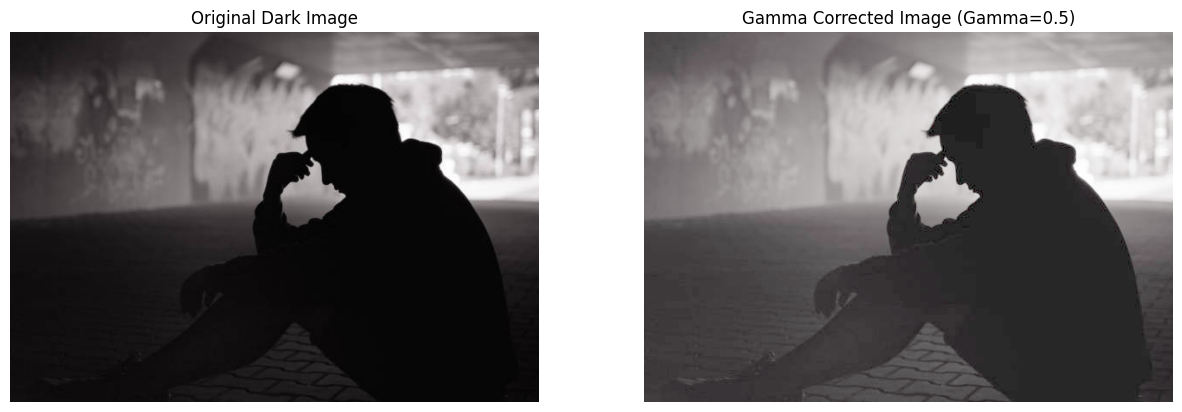

Gamma correction applied and images displayed for comparison.


In [51]:
gamma_value = 0.5 # A lower gamma value brightens the image

# Create a lookup table for gamma correction
lookup_table = np.array([255 * ((i / 255.0) ** gamma_value) for i in np.arange(0, 256)]).astype("uint8")

# Apply gamma correction to the dark image
gamma_corrected_dark_image_rgb = cv2.LUT(dark_image_rgb, lookup_table)

# Display original and gamma-corrected images side-by-side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(dark_image_rgb)
plt.title('Original Dark Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected_dark_image_rgb)
plt.title(f'Gamma Corrected Image (Gamma={gamma_value})')
plt.axis('off')

plt.show()

print("Gamma correction applied and images displayed for comparison.")

## Load and Display Low-Contrast Image



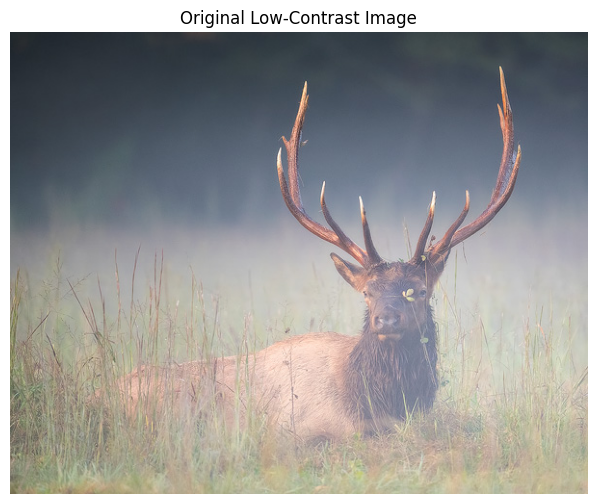

Successfully loaded and displayed 'low contrast.jpg'.


In [52]:
low_contrast_image_path = os.path.join(local_image_dir, "low contrast.jpg")
low_contrast_image_bgr = cv2.imread(low_contrast_image_path)
low_contrast_image_rgb = cv2.cvtColor(low_contrast_image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(low_contrast_image_rgb)
plt.title('Original Low-Contrast Image')
plt.axis('off')
plt.show()

print(f"Successfully loaded and displayed '{os.path.basename(low_contrast_image_path)}'.")

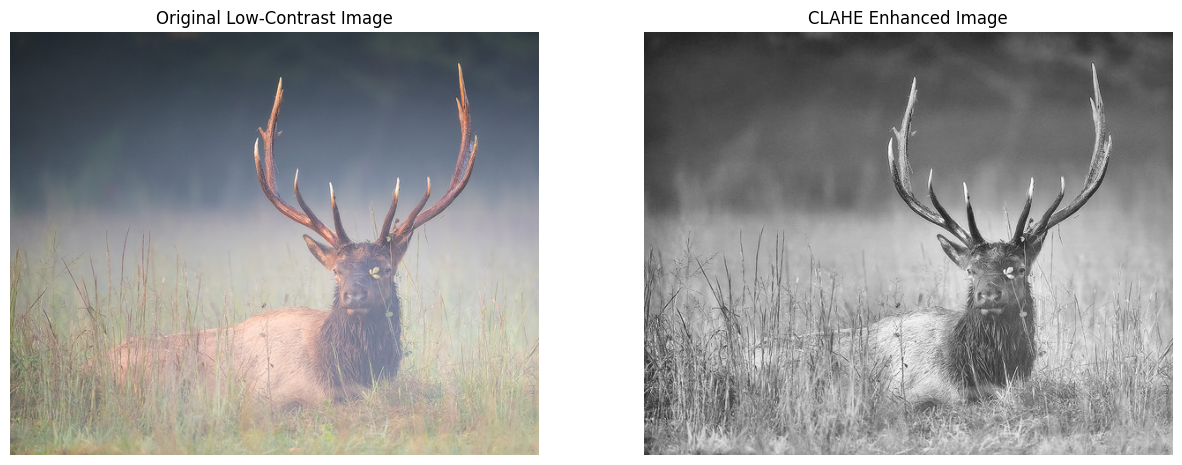

CLAHE applied and images displayed for comparison.


In [53]:
low_contrast_image_gray = cv2.cvtColor(low_contrast_image_rgb, cv2.COLOR_RGB2GRAY)

# Create a CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# Apply CLAHE to the grayscale image
clahe_enhanced_gray = clahe.apply(low_contrast_image_gray)

# Convert the enhanced grayscale image back to RGB for display (optional, but good for consistency)
clahe_enhanced_low_contrast_image_rgb = cv2.cvtColor(clahe_enhanced_gray, cv2.COLOR_GRAY2RGB)

# Display original and CLAHE enhanced images side-by-side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(low_contrast_image_rgb)
plt.title('Original Low-Contrast Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clahe_enhanced_low_contrast_image_rgb)
plt.title('CLAHE Enhanced Image')
plt.axis('off')

plt.show()

print("CLAHE applied and images displayed for comparison.")

## Load and Display Blurred Image


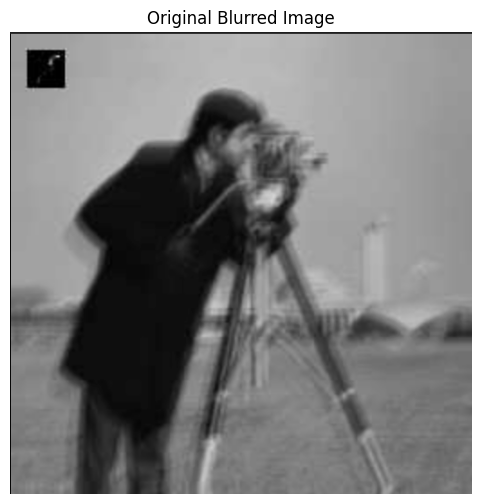

Successfully loaded and displayed 'blurry.jpg'.


In [54]:
blurred_image_path = os.path.join(local_image_dir, "blurry.jpg")
blurred_image_bgr = cv2.imread(blurred_image_path)
blurred_image_rgb = cv2.cvtColor(blurred_image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(blurred_image_rgb)
plt.title('Original Blurred Image')
plt.axis('off')
plt.show()

print(f"Successfully loaded and displayed '{os.path.basename(blurred_image_path)}'.")

## Enhance Blurred Image (Sharpening Filter)



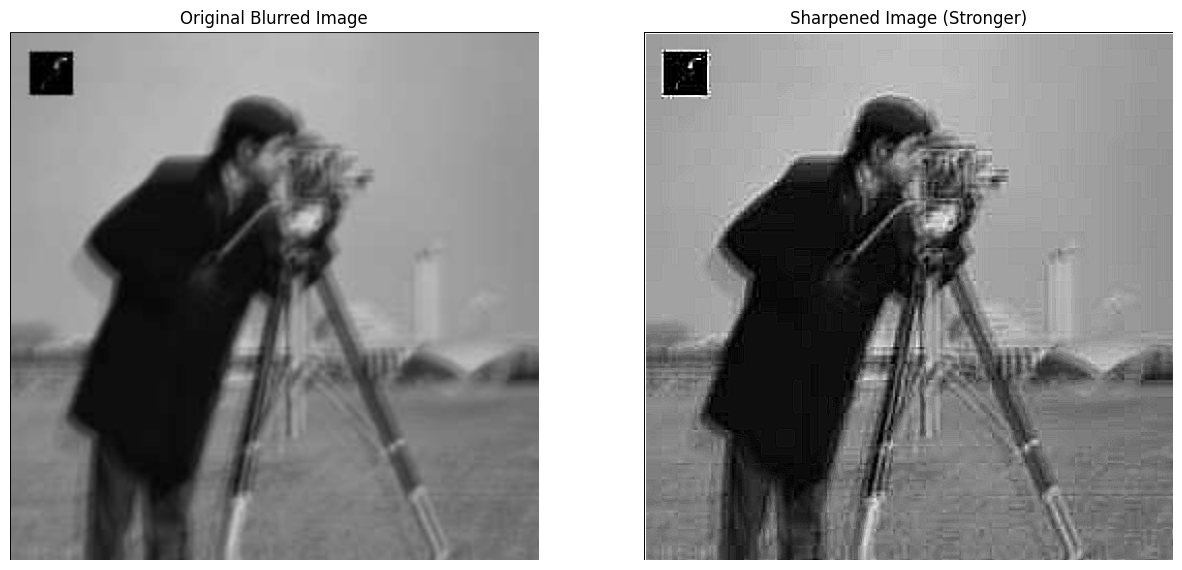

Sharpening filter applied and images displayed for comparison.


In [58]:
sharpen_kernel = np.array([[-1, -1, -1],
                           [-1, 9, -1],
                           [-1, -1, -1]])

# Apply the sharpening filter
sharpened_blurred_image_rgb = cv2.filter2D(blurred_image_rgb, -1, sharpen_kernel)

# Display original and sharpened images side-by-side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(blurred_image_rgb)
plt.title('Original Blurred Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sharpened_blurred_image_rgb)
plt.title('Sharpened Image (Stronger)')
plt.axis('off')

plt.show()

print("Sharpening filter applied and images displayed for comparison.")

## Load and Display Bright Image



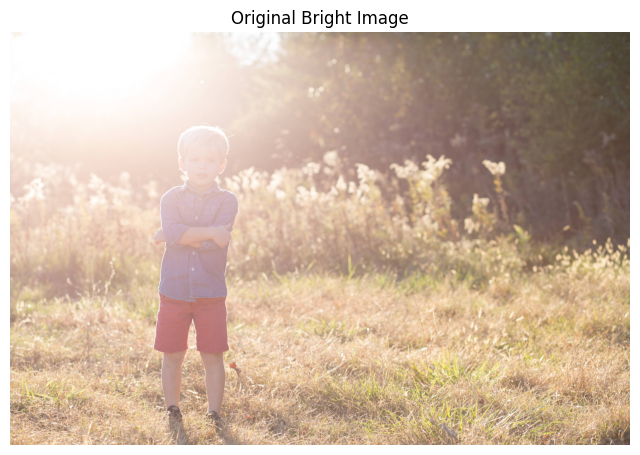

Successfully loaded and displayed 'too bright.jpg'.


In [56]:
bright_image_path = os.path.join(local_image_dir, "too bright.jpg")
bright_image_bgr = cv2.imread(bright_image_path)
bright_image_rgb = cv2.cvtColor(bright_image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(bright_image_rgb)
plt.title('Original Bright Image')
plt.axis('off')
plt.show()

print(f"Successfully loaded and displayed '{os.path.basename(bright_image_path)}'.")

## Enhance Bright Image (Intensity Scaling or Gamma Adjustment)

### Subtask:
Apply intensity scaling or gamma adjustment to the bright image to reduce overexposure and reveal details. Display the original and the enhanced image side-by-side for comparison.

**Reasoning**:
To correct the overexposed bright image, I will apply gamma correction with a gamma value greater than 1.0 to darken it, similar to the dark image correction but with an inverse effect, and then display it alongside the original for comparison, as instructed by the subtask.



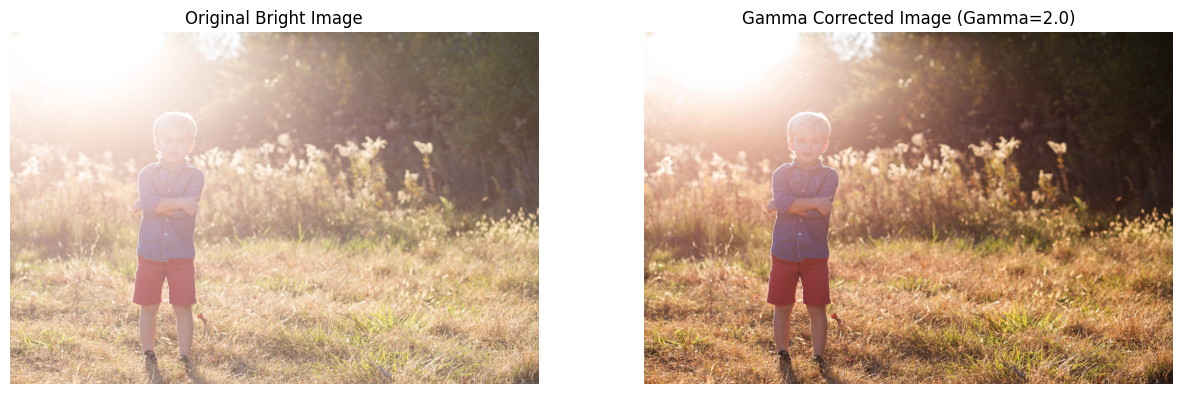

Gamma correction applied to bright image and images displayed for comparison.


In [57]:
gamma_value_bright = 2.0 # A higher gamma value darkens the image

# Create a lookup table for gamma correction
lookup_table_bright = np.array([255 * ((i / 255.0) ** gamma_value_bright) for i in np.arange(0, 256)]).astype("uint8")

# Apply gamma correction to the bright image
gamma_corrected_bright_image_rgb = cv2.LUT(bright_image_rgb, lookup_table_bright)

# Display original and gamma-corrected images side-by-side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(bright_image_rgb)
plt.title('Original Bright Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected_bright_image_rgb)
plt.title(f'Gamma Corrected Image (Gamma={gamma_value_bright})')
plt.axis('off')

plt.show()

print("Gamma correction applied to bright image and images displayed for comparison.")